<a href="https://colab.research.google.com/github/parviza9999/Credit-Card-Fraud-Detection-/blob/main/notebooks/04_xgboost_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install xgboost -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
file_path = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/data/raw/creditcard.csv"

df = pd.read_csv(file_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Dataset shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [6]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (227845, 30)
X_test: (56962, 30)

Training class distribution:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Testing class distribution:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (227845, 30)
Scaled testing shape: (56962, 30)


In [9]:
non_fraud_count = y_train.value_counts()[0]
fraud_count = y_train.value_counts()[1]

scale_pos_weight = non_fraud_count / fraud_count

print("Non-fraud training count:", non_fraud_count)
print("Fraud training count:", fraud_count)
print("scale_pos_weight:", scale_pos_weight)

Non-fraud training count: 227451
Fraud training count: 394
scale_pos_weight: 577.2868020304569


In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


In [11]:
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated.")

Predictions generated.


In [12]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Fraud", "Actual Fraud"],
    columns=["Predicted Non-Fraud", "Predicted Fraud"]
)

cm_df

,Predicted Non-Fraud,Predicted Fraud
Actual Non-Fraud,56801,63
Actual Fraud,12,86


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc],
    "PR-AUC": [pr_auc]
})

xgb_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.998683,0.577181,0.877551,0.696356,0.983146,0.85812


In [14]:
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.58      0.88      0.70        98

    accuracy                           1.00     56962
   macro avg       0.79      0.94      0.85     56962
weighted avg       1.00      1.00      1.00     56962



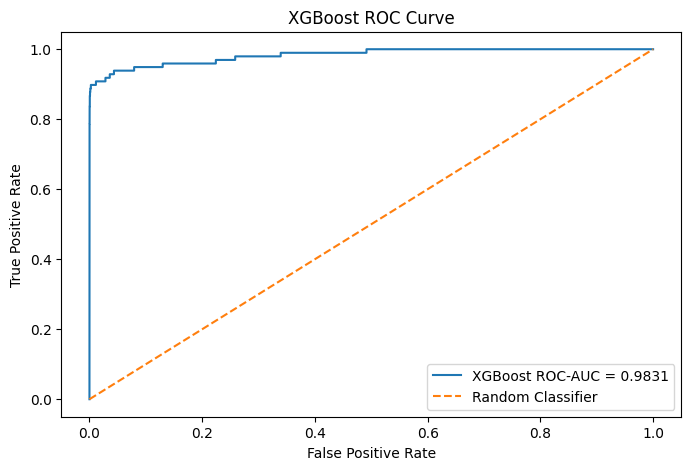

In [15]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"XGBoost ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

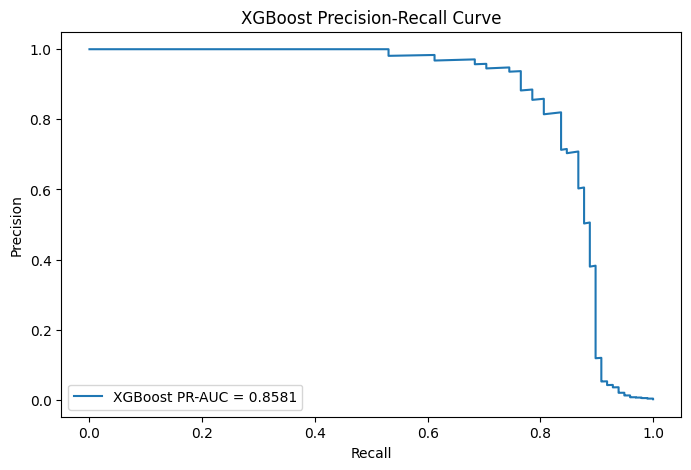

In [16]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f"XGBoost PR-AUC = {pr_auc:.4f}")
plt.title("XGBoost Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
14,V14,0.334053
4,V4,0.114741
10,V10,0.070661
20,V20,0.045499
17,V17,0.030552
11,V11,0.028670
12,V12,0.028290
8,V8,0.026077
7,V7,0.025066
29,Amount,0.024754


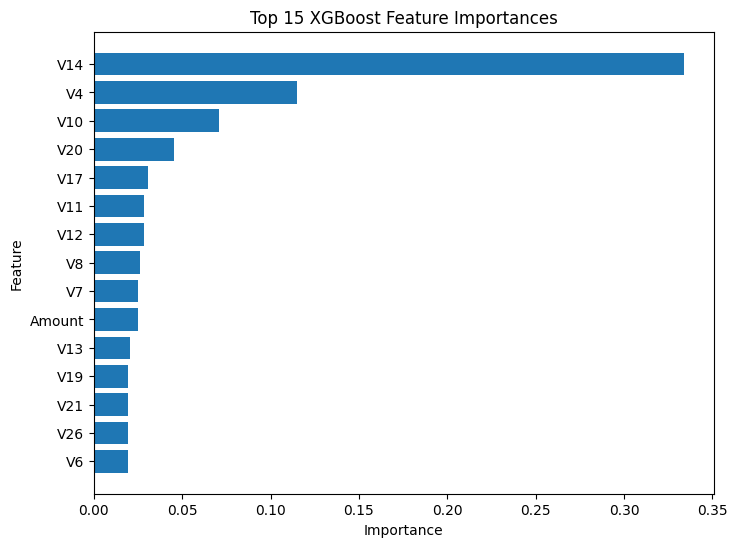

In [18]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "False Positives": confusion_matrix(y_test, y_pred_threshold)[0, 1],
        "False Negatives": confusion_matrix(y_test, y_pred_threshold)[1, 0]
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.1,0.171540,0.897959,0.288052,425,10
1,0.2,0.309859,0.897959,0.460733,196,10
2,0.3,0.406542,0.887755,0.557692,127,11
3,0.4,0.500000,0.887755,0.639706,87,11
4,0.5,0.577181,0.877551,0.696356,63,12
5,0.6,0.629630,0.867347,0.729614,50,13
6,0.7,0.696721,0.867347,0.772727,37,13
7,0.8,0.725664,0.836735,0.777251,31,16
8,0.9,0.811881,0.836735,0.824121,19,16


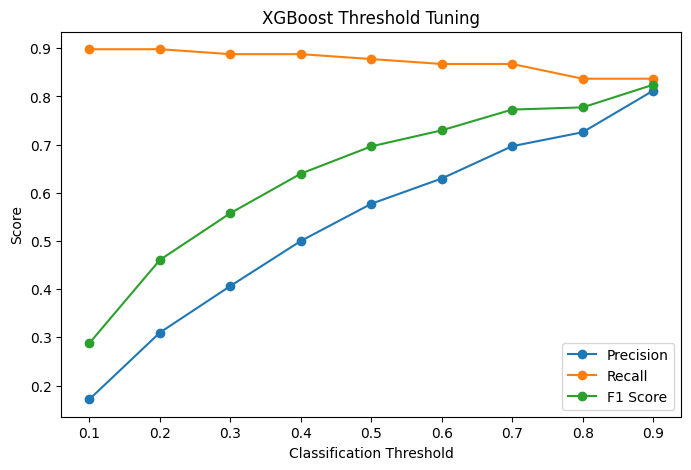

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1 Score"], marker="o", label="F1 Score")
plt.title("XGBoost Threshold Tuning")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [21]:
best_threshold_row = threshold_results_df.sort_values("F1 Score", ascending=False).iloc[0]

best_threshold = best_threshold_row["Threshold"]

best_threshold_row

,8
Threshold,0.900000
Precision,0.811881
Recall,0.836735
F1 Score,0.824121
False Positives,19.000000
False Negatives,16.000000


In [22]:
y_pred_best = (y_proba >= best_threshold).astype(int)

final_cm = confusion_matrix(y_test, y_pred_best)

final_cm_df = pd.DataFrame(
    final_cm,
    index=["Actual Non-Fraud", "Actual Fraud"],
    columns=["Predicted Non-Fraud", "Predicted Fraud"]
)

final_cm_df

,Predicted Non-Fraud,Predicted Fraud
Actual Non-Fraud,56845,19
Actual Fraud,16,82


In [23]:
final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)
final_roc_auc = roc_auc_score(y_test, y_proba)
final_pr_auc = average_precision_score(y_test, y_proba)

xgb_tuned_results = pd.DataFrame({
    "Model": ["XGBoost Tuned Threshold"],
    "Threshold": [best_threshold],
    "Accuracy": [final_accuracy],
    "Precision": [final_precision],
    "Recall": [final_recall],
    "F1 Score": [final_f1],
    "ROC-AUC": [final_roc_auc],
    "PR-AUC": [final_pr_auc]
})

xgb_tuned_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost Tuned Threshold,0.9,0.999386,0.811881,0.836735,0.824121,0.983146,0.85812


In [24]:
model_output_folder = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/model_artifacts"
report_output_folder = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/reports"

import os
os.makedirs(model_output_folder, exist_ok=True)
os.makedirs(report_output_folder, exist_ok=True)

joblib.dump(xgb_model, f"{model_output_folder}/xgboost_fraud_model.joblib")
joblib.dump(scaler, f"{model_output_folder}/xgboost_scaler.joblib")

xgb_results.to_csv(f"{report_output_folder}/xgboost_default_results.csv", index=False)
xgb_tuned_results.to_csv(f"{report_output_folder}/xgboost_tuned_results.csv", index=False)
threshold_results_df.to_csv(f"{report_output_folder}/xgboost_threshold_results.csv", index=False)
feature_importance.to_csv(f"{report_output_folder}/xgboost_feature_importance.csv", index=False)

print("Model, scaler, and reports saved successfully.")

Model, scaler, and reports saved successfully.


## XGBoost Model Summary

The XGBoost supervised classification model was trained using the Credit Card Fraud Detection dataset. Because the dataset is highly imbalanced, the model used `scale_pos_weight` to increase the penalty for misclassifying fraud transactions.

The evaluation focused on fraud-sensitive metrics including precision, recall, F1-score, ROC-AUC, PR-AUC, and the confusion matrix. Accuracy was reported but was not treated as the primary success metric because fraudulent transactions represent only a very small percentage of the dataset.

Threshold tuning was also performed because the default classification threshold of 0.50 may not provide the best balance between fraud recall and false positives. The recommended threshold was selected based on F1-score, but the final deployment threshold may be adjusted depending on the business priority between catching more fraud and reducing false alarms.

Key outputs saved:
- XGBoost trained model
- StandardScaler object
- Default model metrics
- Tuned-threshold metrics
- Threshold comparison table
- Feature importance table